Regression techniques to predict home prices
https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/data


## Step 1: Load Data

In [ ]:
# Data is included in the repository — load directly


## Step 2: Process and Visualize the data

In [ ]:
import pandas as pd
df = pd.read_csv("train.csv")
df

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [ ]:
from matplotlib import pyplot as plt
%matplotlib inline

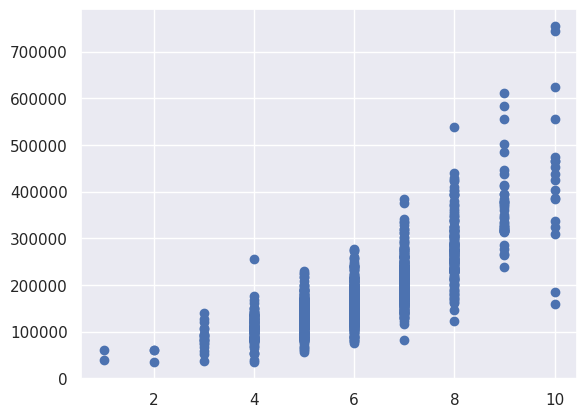

In [ ]:
plt.scatter(df['OverallQual'],df['SalePrice'])

## Step 3: Cleanup the Data

In [ ]:
from sklearn.preprocessing import LabelEncoder

for col in df.columns:
  if pd.api.types.is_numeric_dtype(df[col].dtype):
    if df[col].isnull().any():
      df[col].fillna(df[col].median(), inplace=True)
  else:
    df[col] = LabelEncoder().fit_transform(df[col])

df

In [ ]:
plt.scatter(df['LotShape'],df['SalePrice'])

<Axes: >

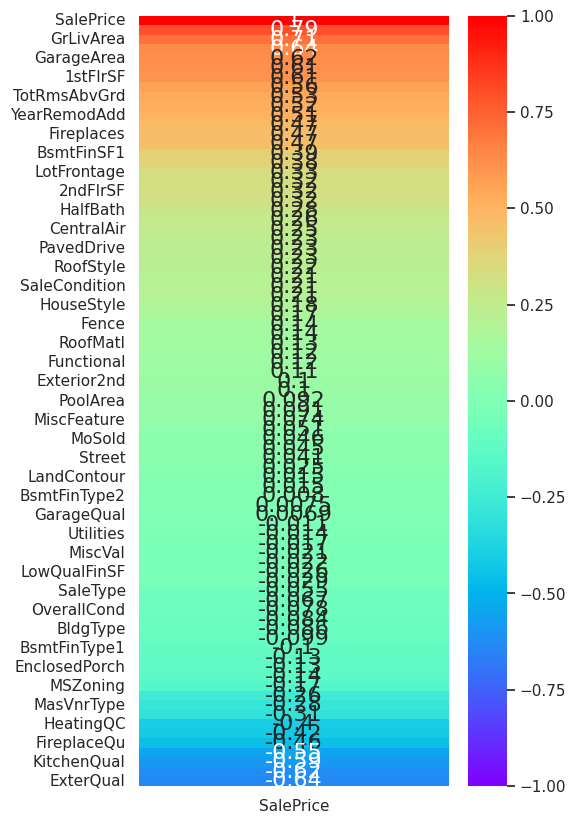

In [ ]:
import seaborn as sns
sns.set()

top_features = df.corr()[['SalePrice']].sort_values(by=['SalePrice'],ascending=False)
plt.figure(figsize=(5,10))
sns.heatmap(top_features,cmap='rainbow', annot=True,annot_kws={"size": 16}, vmin=-1)


In [ ]:
top_features = df.corr()
top_features

## Step 4: Setup the Training sets

In [ ]:
y = df["SalePrice"]
X = df.drop("SalePrice",axis="columns")
y

,SalePrice
0,208500
1,181500
2,223500
3,140000
4,250000
...,...
1455,175000
1456,210000
1457,266500
1458,142125


In [ ]:
X

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
254,255,20,3,70.0,8400,1,2,3,3,0,...,0,0,3,4,4,0,6,2010,8,4
1066,1067,60,3,59.0,7837,1,2,0,3,0,...,0,0,3,4,4,0,5,2009,8,4
638,639,30,3,67.0,8777,1,2,3,3,0,...,0,0,3,2,4,0,5,2008,8,4
799,800,50,3,60.0,7200,1,2,3,3,0,...,0,0,3,2,4,0,6,2007,8,4
380,381,50,3,50.0,5000,1,1,3,3,0,...,0,0,3,4,4,0,5,2010,8,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1095,1096,20,3,78.0,9317,1,2,0,3,0,...,0,0,3,4,4,0,3,2007,8,4
1130,1131,50,3,65.0,7804,1,2,3,3,0,...,0,0,3,2,4,0,12,2009,8,4
1294,1295,20,3,60.0,8172,1,2,3,3,0,...,0,0,3,4,4,0,4,2006,8,4
860,861,50,3,55.0,7642,1,2,3,3,0,...,0,0,3,0,4,0,6,2007,8,4


## Step 5: Train the data

In [ ]:
from sklearn.linear_model import LinearRegression
trainer = LinearRegression()
trainer.fit(X_train,y_train)

LinearRegression()

In [ ]:
import xgboost as xgb
trainer2 = xgb.XGBRegressor()
trainer2.fit(X_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

## Step 6: Score and Understand

In [ ]:
trainer.score(X_test,y_test)

In [ ]:
trainer2.score(X_test,y_test)

In [ ]:
import pickle
with open('model.pkl', 'wb') as file:
    pickle.dump(trainer, file)

In [ ]:
y_test

In [ ]:
print("Coefficients (slopes) of the parameters:")
for feature, coef in zip(trainer.feature_names_in_, trainer.coef_):
    print(f"{feature}: {coef}")

Coefficients (slopes) of the parameters:
Id: -2.6944940824929096
MSSubClass: -132.06223627528462
MSZoning: -2096.941999911039
LotFrontage: -257.1477298263559
LotArea: 0.35867566015103236
Street: 19024.521679558362
Alley: 4500.218072045673
LotShape: -1072.6486552612232
LandContour: 3094.0074311101507
Utilities: -56222.54698151965
LotConfig: 81.38545584308969
LandSlope: 10953.99675049981
Neighborhood: 414.18439214510624
Condition1: -801.4885662992046
Condition2: -10890.935089723807
BldgType: -2266.987144179415
HouseStyle: -880.8651430943196
OverallQual: 10856.868166438857
OverallCond: 5063.346814082677
YearBuilt: 215.26366777822415
YearRemodAdd: 47.59131221908967
RoofStyle: 2550.650603726298
RoofMatl: 5551.666533061562
Exterior1st: -1504.9323147932505
Exterior2nd: 832.6697177834416
MasVnrType: 4678.487135731586
MasVnrArea: 36.83422671192807
ExterQual: -8423.239278007308
ExterCond: 388.3074330450572
Foundation: 831.0597031809599
BsmtQual: -9727.101029281392
BsmtCond: 3315.559375890983
Bsm

In [ ]:
# Let's pick a random house and check the results
import random
my_choice = random.randrange(len(X_test))
print(my_choice)
print("Actual price: ", y_test.iloc[my_choice], "Predicted Price: ", trainer.predict(X_test.iloc[[my_choice]]))

## Step 7: Deploy

In [ ]:
import gradio as gr
import numpy as np

# 1. Pick 5-8 intuitive ones from the top
slider_features = [
    'GrLivArea',      # Square footage - intuitive
    'OverallQual',    # Quality rating 1-10
    'TotalBsmtSF',    # Basement size
    'GarageCars',     # Garage capacity
    'FullBath',       # Number of bathrooms
    'YearBuilt',      # Age of home
    'LotArea',        # Lot size
    # Add 3-5 more based on your importance ranking
]

# 2. Store medians for all columns
medians = X_train.median()

# 3. Prediction function
def predict(**kwargs):
    input_data = medians.copy()
    for feature, value in kwargs.items():
        input_data[feature] = value
    pred = trainer.predict([input_data[X_train.columns]])[0]
    return f"${pred:,.0f}"

# 5. Build sliders automatically
sliders = []
for feat in slider_features:
    sliders.append(gr.Slider(
        minimum=float(X_train[feat].min()),
        maximum=float(X_train[feat].max()),
        value=float(medians[feat]),
        label=feat
    ))

# 6. Launch
gr.Interface(
    fn=lambda *args: predict(**dict(zip(slider_features, args))),
    inputs=sliders,
    outputs="text",
    title="Home Price Predictor"
).launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://8bcdc5a89aebaf6cf9.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
